In [199]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [200]:
df = pd.read_csv(r"D:\collage\sem 8\ssdi\Auto.csv", na_values="?").dropna()

In [201]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.6+ KB


In [203]:
# Target mpg

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt

In [205]:
scaler = StandardScaler()
df[['displacement', 'horsepower', 'weight','acceleration']] = scaler.fit_transform(df[['displacement', 'horsepower', 'weight','acceleration']])

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')

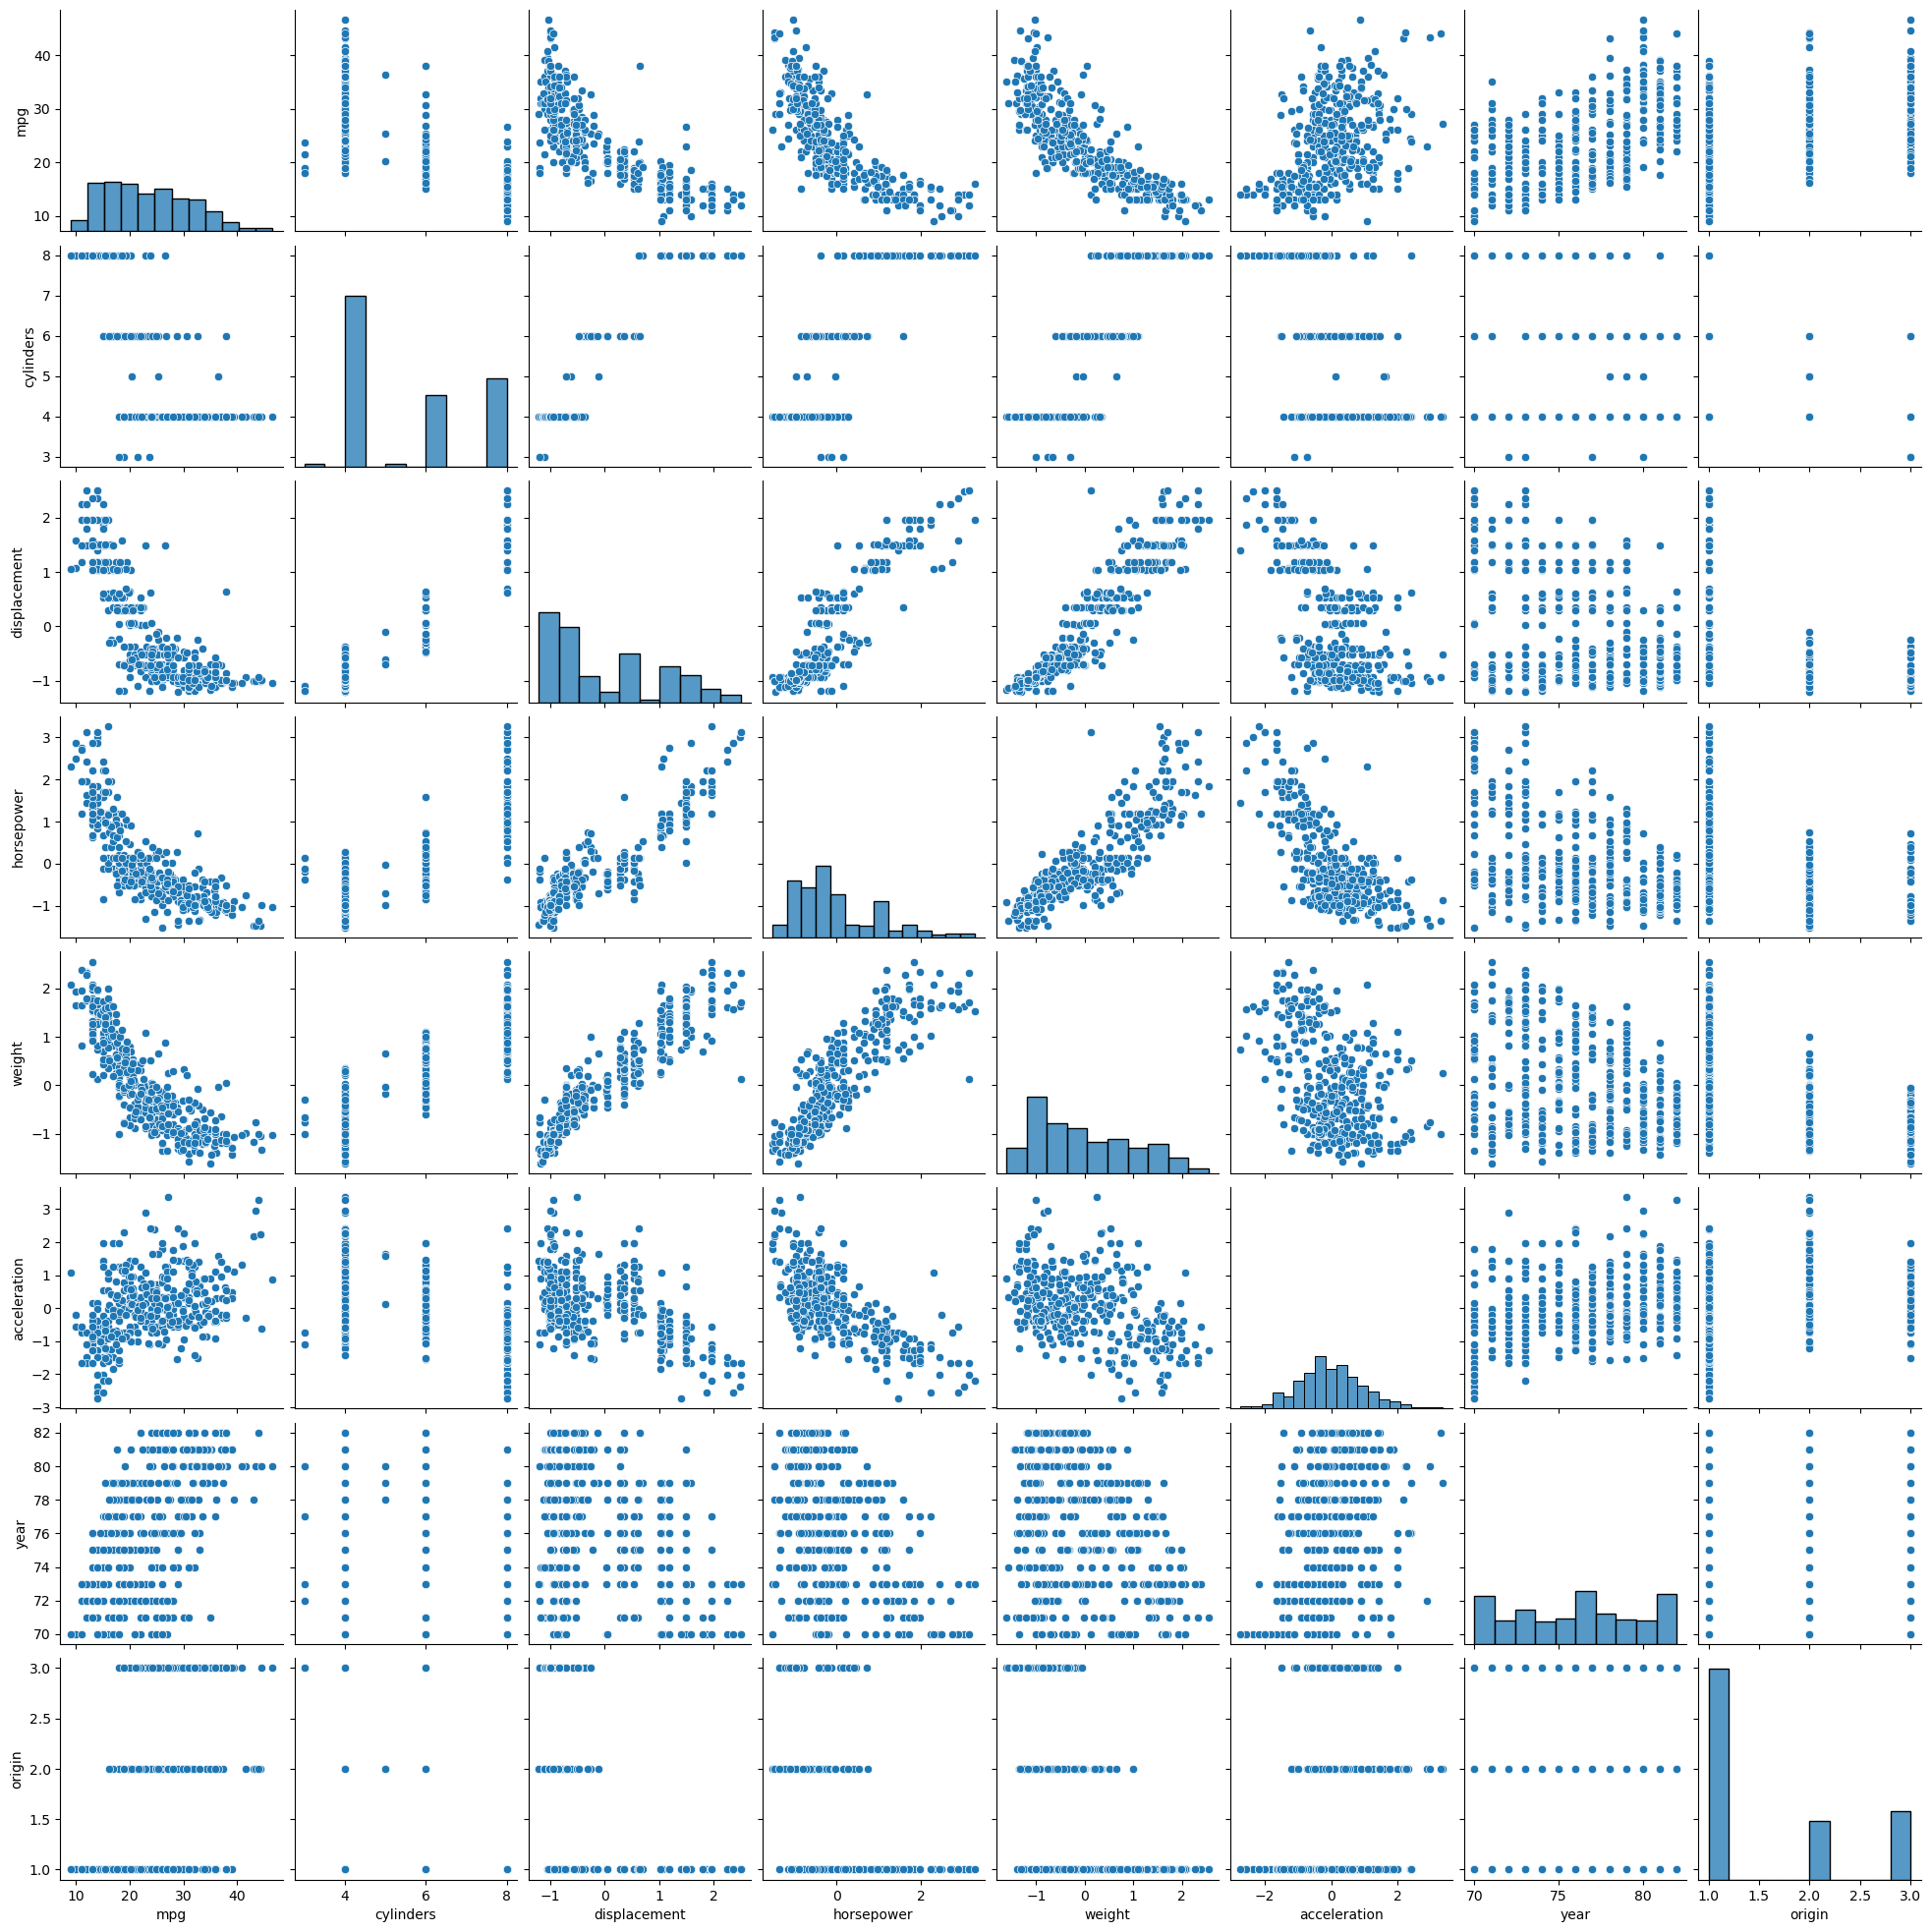

In [206]:
sns.pairplot(df)
df.columns

#cat: cylinders, orgin
#cont: 'displacement', 'horsepower', 'weight','acceleration'

<Axes: xlabel='mpg', ylabel='horsepower'>

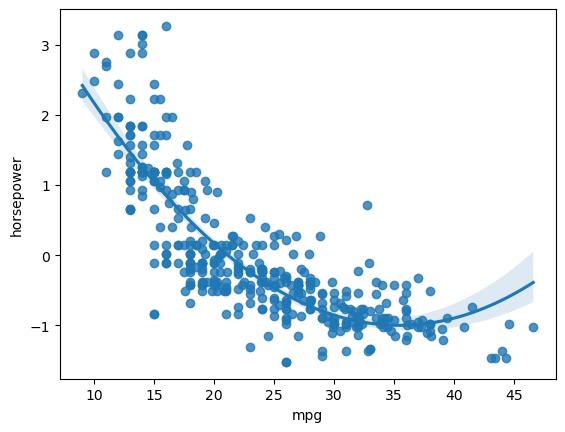

In [207]:
sns.regplot(x = "mpg", y = "horsepower", data=df, order=2)

<Axes: xlabel='mpg', ylabel='weight'>

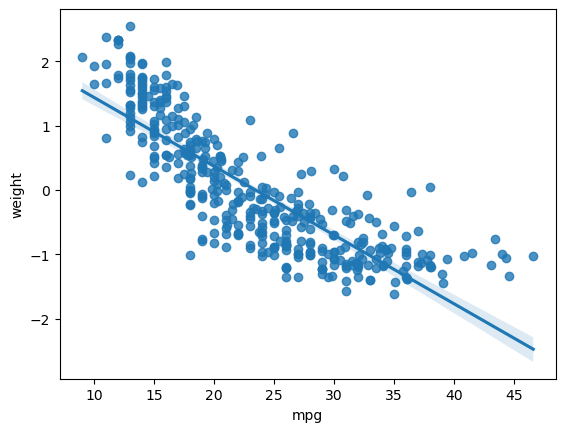

In [208]:
sns.regplot(x = "mpg", y = "weight", data=df)

In [209]:
df["hp2"] = df["horsepower"].values ** 2
df["d2"] = df["displacement"].values ** 2
df["w2"] = df["weight"].values ** 2
df["acc2"] = df["acceleration"].values ** 2

lm = smf.ols("mpg ~ horsepower + hp2", df).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     428.0
Date:                Thu, 07 May 2026   Prob (F-statistic):           5.40e-99
Time:                        21:17:28   Log-Likelihood:                -1133.2
No. Observations:                 392   AIC:                             2272.
Df Residuals:                     389   BIC:                             2284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     21.6274      0.285     75.828      0.000      21.067      22.188
horsepower    -8.0376      0.295    -27.252      0.000      -8.617      -7.458
hp2            1.8185      0.180     10.080      0.000       1.464       2.173
==============================================================================
Omnibus:                       16.158   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.662
Skew:                           0.218   Prob(JB):                     2.20e-07
Kurtosis:                       4.299   Cond. No.                         3.53
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [210]:
lm = smf.ols("mpg ~ displacement + d2", df).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.689
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     430.5
Date:                Thu, 07 May 2026   Prob (F-statistic):           2.48e-99
Time:                        21:17:28   Log-Likelihood:                -1132.4
No. Observations:                 392   AIC:                             2271.
Df Residuals:                     389   BIC:                             2283.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       21.6052      0.340     63.599      0.000      20.937      22.273
displacement    -7.5626      0.285    -26.533      0.000      -8.123      -7.002
d2               1.8407      0.258      7.122      0.000       1.333       2.349
==============================================================================
Omnibus:                       43.407   Durbin-Watson:                   0.941
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              104.593
Skew:                           0.559   Prob(JB):                     1.94e-23
Kurtosis:                       5.270   Cond. No.                         3.48
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [211]:
lm = smf.ols("mpg ~ weight + w2", df).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     488.3
Date:                Thu, 07 May 2026   Prob (F-statistic):          8.39e-107
Time:                        21:17:28   Log-Likelihood:                -1115.1
No. Observations:                 392   AIC:                             2236.
Df Residuals:                     389   BIC:                             2248.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.2250      0.305     72.890      0.000      21.626      22.824
weight        -7.1193      0.240    -29.694      0.000      -7.591      -6.648
w2             1.2209      0.220      5.545      0.000       0.788       1.654
==============================================================================
Omnibus:                       53.804   Durbin-Watson:                   0.770
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               93.923
Skew:                           0.809   Prob(JB):                     4.03e-21
Kurtosis:                       4.770   Cond. No.                         2.99
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [212]:
lm = smf.ols("mpg ~ acceleration + acc2", df).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     46.80
Date:                Thu, 07 May 2026   Prob (F-statistic):           6.11e-19
Time:                        21:17:28   Log-Likelihood:                -1318.9
No. Observations:                 392   AIC:                             2644.
Df Residuals:                     389   BIC:                             2656.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       24.0651      0.424     56.764      0.000      23.232      24.899
acceleration     3.4797      0.361      9.634      0.000       2.770       4.190
acc2            -0.6192      0.232     -2.669      0.008      -1.075      -0.163
==============================================================================
Omnibus:                       16.240   Durbin-Watson:                   0.681
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.243
Skew:                           0.496   Prob(JB):                     0.000180
Kurtosis:                       2.729   Cond. No.                         2.49
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [213]:
lm = smf.ols("mpg ~ + horsepower + hp2", df).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     428.0
Date:                Thu, 07 May 2026   Prob (F-statistic):           5.40e-99
Time:                        21:17:28   Log-Likelihood:                -1133.2
No. Observations:                 392   AIC:                             2272.
Df Residuals:                     389   BIC:                             2284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     21.6274      0.285     75.828      0.000      21.067      22.188
horsepower    -8.0376      0.295    -27.252      0.000      -8.617      -7.458
hp2            1.8185      0.180     10.080      0.000       1.464       2.173
==============================================================================
Omnibus:                       16.158   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.662
Skew:                           0.218   Prob(JB):                     2.20e-07
Kurtosis:                       4.299   Cond. No.                         3.53
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [214]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

In [215]:
# get dummies on cats

df = pd.get_dummies(df, columns=["cylinders", "origin"], drop_first=True) #one hottie encoding

In [216]:
df

,mpg,displacement,horsepower,weight,acceleration,year,name,hp2,d2,w2,acc2,cylinders_4,cylinders_5,cylinders_6,cylinders_8,origin_2,origin_3
0,18.0,1.077290,0.664133,0.620540,-1.285258,70,chevrolet chevelle malibu,0.441072,1.160553,0.385070,1.651888,False,False,False,True,False,False
1,15.0,1.488732,1.574594,0.843334,-1.466724,70,buick skylark 320,2.479348,2.216322,0.711212,2.151278,False,False,False,True,False,False
2,18.0,1.182542,1.184397,0.540382,-1.648189,70,plymouth satellite,1.402795,1.398406,0.292012,2.716528,False,False,False,True,False,False
3,16.0,1.048584,1.184397,0.536845,-1.285258,70,amc rebel sst,1.402795,1.099529,0.288203,1.651888,False,False,False,True,False,False
4,17.0,1.029447,0.924265,0.555706,-1.829655,70,ford torino,0.854265,1.059762,0.308809,3.347637,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392,27.0,-0.520637,-0.480448,-0.221125,0.021294,82,ford mustang gl,0.230830,0.271063,0.048896,0.000453,True,False,False,False,False,False
393,44.0,-0.932079,-1.364896,-0.999134,3.287676,82,vw pickup,1.862942,0.868771,0.998270,10.808810,True,False,False,False,True,False
394,32.0,-0.568479,-0.532474,-0.804632,-1.430430,82,dodge rampage,0.283529,0.323168,0.647433,2.046131,True,False,False,False,False,False
395,28.0,-0.712005,-0.662540,-0.415627,1.110088,82,ford ranger,0.438959,0.506952,0.172746,1.232296,True,False,False,False,False,False


In [232]:
# using vif:

# use all cont variables , remove one by one the highest value till all are less than 5
x = df[['weight', 'acceleration']]
y = df["mpg"]

x = x.astype(float)
x = add_constant(x)

vif = pd.DataFrame()
vif["Features"] = x.columns
vif["vif"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

vif

,Features,vif
0,const,1.000000
1,weight,1.210295
2,acceleration,1.210295


In [233]:
df.columns

Index(['mpg', 'displacement', 'horsepower', 'weight', 'acceleration', 'year',
       'name', 'hp2', 'd2', 'w2', 'acc2', 'cylinders_4', 'cylinders_5',
       'cylinders_6', 'cylinders_8', 'origin_2', 'origin_3'],
      dtype='object')

In [234]:
x = df[['weight', 'acceleration', 'cylinders_4', 'cylinders_5',
       'cylinders_6', 'cylinders_8', 'origin_2', 'origin_3']]


alphas = 10**np.linspace(10,-2,100)*0.5
ridge = Ridge()
coefs = []

for a in alphas:
    ridge.set_params(alpha = a)
    ridge.fit(x,y)
    coefs.append(ridge.coef_)
np.shape(coefs)

(100, 8)

In [235]:
lasso = Lasso()
coefs = []

for a in alphas:
    lasso.set_params(alpha = a)
    lasso.fit(x,y)
    coefs.append(lasso.coef_)
np.shape(coefs)

(100, 8)

In [236]:
ridgecv = RidgeCV (alphas = alphas)
ridgecv.fit(x,y)
bestalphaR = ridgecv.alpha_ #best alpha
print(bestalphaR)

0.18824679033962358


In [237]:
lassocv = LassoCV(alphas = alphas)
lassocv.fit(x,y)
bestalphaL = lassocv.alpha_ #best alpha
print(bestalphaL)

0.005


In [238]:
fitr = Ridge(alpha = bestalphaR)
fitr.fit(x,y)
fitr.coef_
print(pd.Series(fitr.coef_, index = x.columns))

weight         -4.861738
acceleration    0.730110
cylinders_4     7.507895
cylinders_5     9.897303
cylinders_6     3.942947
cylinders_8     5.177726
origin_2       -0.228431
origin_3        2.108657
dtype: float64


In [239]:
fitl = Lasso (alpha = bestalphaL)
fitl.fit(x,y)
fitl.coef_
print(pd.Series(fitl.coef_, index = x.columns))

weight         -4.817147
acceleration    0.726647
cylinders_4     6.743073
cylinders_5     9.030128
cylinders_6     3.105842
cylinders_8     4.289993
origin_2       -0.211619
origin_3        2.045870
dtype: float64


In [240]:
# dropping acceleration as = 0

In [241]:
lm = smf.ols("mpg ~  weight + acceleration + cylinders_4 + cylinders_5 + cylinders_6 + cylinders_8 + origin_3", df).fit()
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     156.5
Date:                Thu, 07 May 2026   Prob (F-statistic):          2.49e-108
Time:                        21:18:33   Log-Likelihood:                -1096.8
No. Observations:                 392   AIC:                             2210.
Df Residuals:                     384   BIC:                             2241.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              15.5091      2.098      7.392      0.000      11.384      19.635
cylinders_4[T.True]     8.8293      2.086      4.233      0.000       4.728      12.931
cylinders_5[T.True]    11.7858      3.156      3.734      0.000       5.581      17.991
cylinders_6[T.True]     5.4118      2.154      2.512      0.012       1.176       9.648
cylinders_8[T.True]     6.6886      2.284      2.929      0.004       2.198      11.179
origin_3[T.True]        2.2880      0.581      3.940      0.000       1.146       3.430
weight                 -4.8992      0.483    -10.143      0.000      -5.849      -3.949
acceleration            0.7111      0.250      2.839      0.005       0.219       1.204
==============================================================================
Omnibus:                       48.523   Durbin-Watson:                   0.880
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               86.734
Skew:                           0.730   Prob(JB):                     1.47e-19
Kurtosis:                       4.783   Cond. No.                         31.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [242]:
X = df[["acceleration" , "weight" , "cylinders_4" , "cylinders_5" , "cylinders_6" , "cylinders_8" , "origin_3"]]
Y = df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [243]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [244]:
y_pred = model.predict(X_test)
y_pred

array([29.90999764, 25.71157531, 34.08799164, 31.97894446, 25.71316447,
       32.0028107 , 10.93568232, 31.85673074, 19.50259576, 32.21803857,
       15.22627623, 23.66310895, 14.00855733, 31.79771239, 18.58946923,
       27.91099129, 20.59304103, 30.96854794, 26.25133688, 27.27765382,
       21.89528374, 32.09000116, 32.89022973, 18.23087876, 30.54297543,
       28.76910319, 25.68642953, 18.33579176, 32.14721111, 28.01865042,
       13.28864117, 20.15313319, 18.47101751, 29.71122314, 12.59207958,
       32.8870514 , 12.68123046, 30.00224803, 14.70180016, 12.26073507,
       15.29746338, 29.6912818 , 30.38756253, 28.28572616, 11.87513971,
       10.72249776, 19.11907247, 29.33982268, 29.08145653, 30.33455836,
       14.82963552, 31.03032333, 28.77497694, 31.44562992, 21.6612996 ,
       17.89664769, 20.30984347, 21.55840796, 28.6785824 , 30.90731707,
        9.45376794, 20.99847015, 21.95422328, 25.12116249, 29.44378771,
       29.42233603, 26.06876775, 30.2789992 , 20.01961521, 12.75

In [245]:
print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.7072845311904941
14.94036825136781


In [248]:
model = LinearRegression()

k = 10
kfold = KFold (n_splits = k, random_state = 0, shuffle = True)

mse_cv = cross_val_score(model, X, Y, cv=kfold, scoring='neg_mean_squared_error')

print(np.mean(-mse_cv))

16.789232572803073
